In [1]:
import random
from typing import TypedDict,List
from langgraph.graph import StateGraph,START,END

In [2]:
class AgentState(TypedDict):
    player_name:str
    guesses:List[int]
    attempts:int
    lower_bound:int
    upper_bound:int
    lucky_no:int

In [3]:
def setup(state:AgentState)->AgentState:
    state["player_name"]=f'Hi there,{state["player_name"]}'
    state["attempts"]=0
    state["lucky_no"]=15
    return state

In [4]:
def guess(state: AgentState) -> AgentState:
    guess = (state["lower_bound"] + state["upper_bound"]) // 2
    state["guesses"].append(guess)
    state["attempts"] += 1
    return state


In [ ]:
def hint_node(state: AgentState) -> AgentState:
    last_guess = state["guesses"][-1]

    if last_guess > state["lucky_no"]:
        state["upper_bound"] = last_guess - 1
    elif last_guess < state["lucky_no"]:
        state["lower_bound"] = last_guess + 1

    return state


In [6]:
def should_continue(state: AgentState) -> str:
    if state["guesses"][-1] == state["lucky_no"]:
        return "exit"
    if state["attempts"] >= 7:
        return "exit"
    return "continue"


In [7]:
graph = StateGraph(AgentState)

graph.add_node("Setup", setup)
graph.add_node("Guess", guess)
graph.add_node("Hint", hint_node)

graph.add_edge("Setup", "Guess")
graph.add_edge("Guess", "Hint")

graph.add_conditional_edges(
    "Hint",
    should_continue,
    {
        "continue": "Guess",
        "exit": END
    }
)

graph.set_entry_point("Setup")
app = graph.compile()


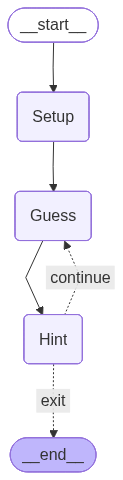

In [8]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
Sample_input=AgentState({"player_name":"Tom","guesses":[],"lower_bound":0,"upper_bound":20,"attempts":0,"lucky_no":0})
print(app.invoke(Sample_input))

{'player_name': 'Hi there,Tom', 'guesses': [10, 15], 'attempts': 2, 'lower_bound': 11, 'upper_bound': 20, 'lucky_no': 15}
